In [9]:
import requests
from bs4 import BeautifulSoup
import tqdm

In [11]:
import requests

url = "https://analytics.opensyllabus.org/record/works"
resp = requests.get(url)

text = resp.text
mid = len(text) // 2
print(text[mid-500 : mid+500])


-orientation="horizontal" class="c-etgOXz" dir="ltr"><li style="align-items:center;display:flex"><a href="https://www.opensyllabus.org/" style="padding-right:12px" class="c-enWIrx c-enWIrx-eNqEOP-layout-one" data-radix-collection-item="">OS Home</a></li><li><button id="radix-:Rapdm:-trigger-exploreMenu" data-state="closed" aria-expanded="false" aria-controls="radix-:Rapdm:-content-exploreMenu" class="c-fYJuh c-fYJuh-eNqEOP-layout-one" data-radix-collection-item="">Explore<svg width="15" height="15" viewBox="0 0 15 15" fill="none" xmlns="http://www.w3.org/2000/svg" aria-hidden="true" class="c-jWivox c-jWivox-eNqEOP-layout-one"><path d="M4.18179 6.18181C4.35753 6.00608 4.64245 6.00608 4.81819 6.18181L7.49999 8.86362L10.1818 6.18181C10.3575 6.00608 10.6424 6.00608 10.8182 6.18181C10.9939 6.35755 10.9939 6.64247 10.8182 6.81821L7.81819 9.81821C7.73379 9.9026 7.61934 9.95001 7.49999 9.95001C7.38064 9.95001 7.26618 9.9026 7.18179 9.81821L4.18179 6.81821C4.00605 6.64247 4.00605 6.35755 4.1817

In [12]:
%pip install playwright

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 9.6 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [playwright]3 [playwright]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
!playwright install firefox

89.9 MiB [                    ] 0% 0.0s89.9 MiB [                    ] 0% 35.1s89.9 MiB [                    ] 0% 40.0s89.9 MiB [                    ] 0% 33.9s89.9 MiB [                    ] 0% 32.5s89.9 MiB [                    ] 0% 32.7s89.9 MiB [                    ] 0% 31.2s89.9 MiB [                    ] 0% 27.4s89.9 MiB [                    ] 0% 25.7s89.9 MiB [                    ] 0% 25.8s89.9 MiB [                    ] 0% 30.4s89.9 MiB [                    ] 1% 20.9s89.9 MiB [                    ] 1% 21.6s89.9 MiB [                    ] 1% 21.2s89.9 MiB [                    ] 1% 20.8s89.9 MiB [                    ] 1% 20.3s89.9 MiB [                    ] 1% 20.6s89.9 MiB [                    ] 1% 19.9s89.9 MiB [                    ] 1% 19.8s89.9 MiB [                    ] 2% 19.8s89.9 MiB [                    ] 2% 19.6s89.9 MiB [                    ] 2% 18.8s89.9 MiB [                    ] 2% 18.4s89.9 MiB [=                   ] 2% 18.6s89.9 MiB [=                   ] 2% 18.3s8

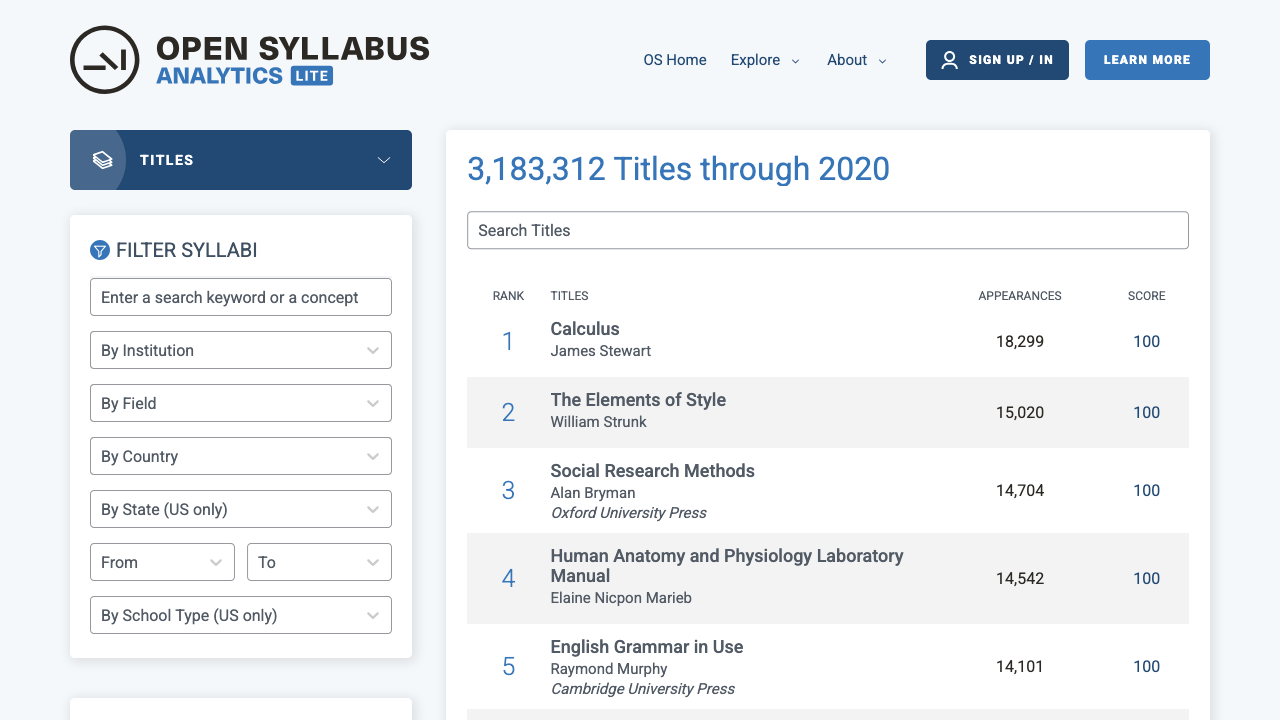

In [15]:
import nest_asyncio
nest_asyncio.apply()

from playwright.async_api import async_playwright
from IPython.display import display, Image
import asyncio

async def open_page():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)  # visible browser
        context = await browser.new_context()
        page = await context.new_page()
        await page.goto("https://analytics.opensyllabus.org/record/works", wait_until="networkidle")
        
        # Take a screenshot to confirm page loaded
        screenshot_bytes = await page.screenshot()
        display(Image(screenshot_bytes))
        
        return page, browser

# Use asyncio.create_task inside Jupyter
page, browser = asyncio.get_event_loop().run_until_complete(open_page())


In [16]:
async def load_all_results(page):
    while True:
        try:
            # Look for the SHOW MORE button
            button = await page.query_selector("button:has-text('SHOW MORE')")
            if not button:
                print("No more SHOW MORE button found. All results loaded!")
                break
            # Click the button
            await button.click()
            print("Clicked SHOW MORE, waiting for more results...")
            await page.wait_for_timeout(2000)  # wait 2 seconds for content to load
        except Exception as e:
            print("Finished loading or error:", e)
            break

# Run in Jupyter
asyncio.get_event_loop().run_until_complete(load_all_results(page))


Finished loading or error: Page.query_selector: Target page, context or browser has been closed


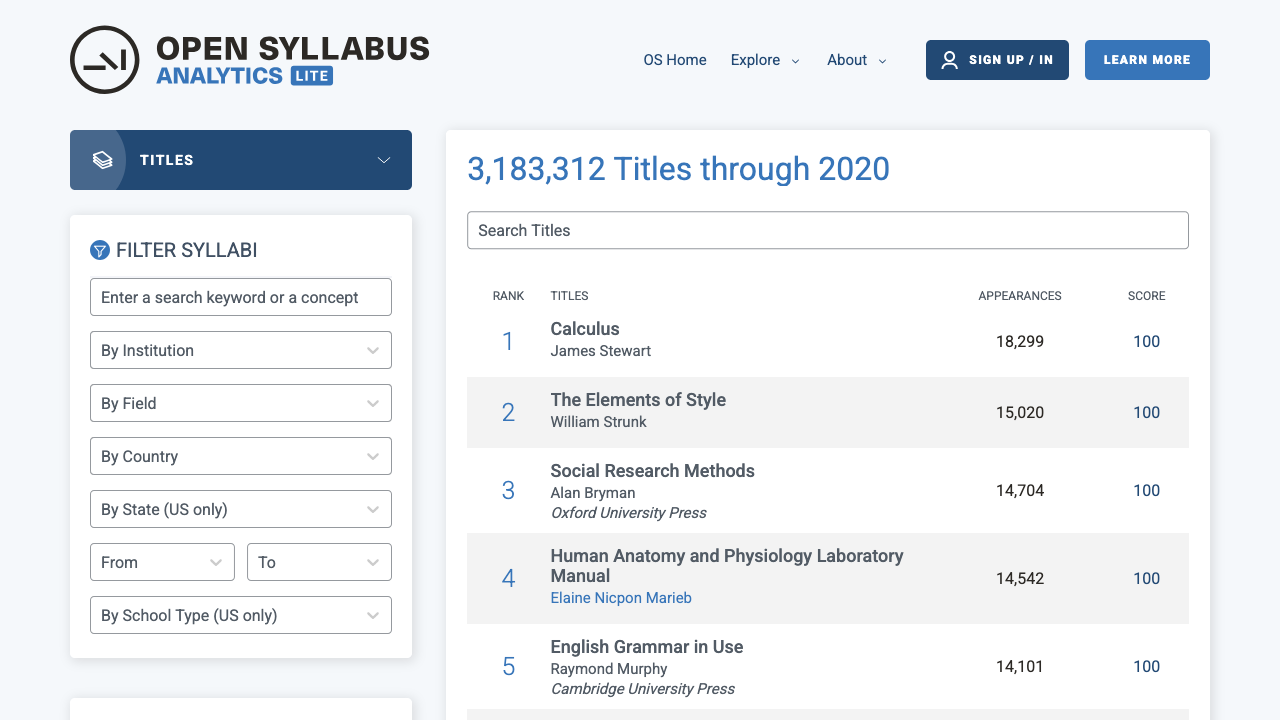

Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
Clicked SHOW MORE, waiting for content to load...
No more SHOW MORE button found. All results loaded!


In [18]:
import nest_asyncio
nest_asyncio.apply()

from playwright.async_api import async_playwright
from IPython.display import display, Image
import asyncio

async def open_and_load_all():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)  # visible
        context = await browser.new_context()
        page = await context.new_page()
        await page.goto("https://analytics.opensyllabus.org/record/works", wait_until="networkidle")
        
        # Take initial screenshot
        screenshot_bytes = await page.screenshot()
        display(Image(screenshot_bytes))
        
        # Click SHOW MORE until done
        while True:
            button = await page.query_selector("button:has-text('SHOW MORE')")
            if not button:
                print("No more SHOW MORE button found. All results loaded!")
                break
            await button.click()
            print("Clicked SHOW MORE, waiting for content to load...")
            await page.wait_for_timeout(2000)  # wait 2 seconds

        return page, browser

# Run it in Jupyter
page, browser = asyncio.get_event_loop().run_until_complete(open_and_load_all())


In [19]:
from bs4 import BeautifulSoup
import pandas as pd

# Get the page content
html = asyncio.get_event_loop().run_until_complete(page.content())

# Parse with BeautifulSoup
soup = BeautifulSoup(html, "html.parser")

# Find all rows
rows = soup.select("tr.sc-9d100f21-6")  # the class from your earlier HTML snippet

# Extract data
data = []
for row in rows:
    rank = row.select_one("td:nth-of-type(1) p").get_text(strip=True)
    title = row.select_one("td:nth-of-type(2) li.sc-9d100f21-24 a p").get_text(strip=True)
    author_tag = row.select_one("td:nth-of-type(2) li.sc-9d100f21-24 cjFXUz a p")
    author = author_tag.get_text(strip=True) if author_tag else ""
    score = row.select_one("td:nth-of-type(4) p").get_text(strip=True)
    usage_count = row.select_one("td:nth-of-type(3) div").get_text(strip=True)
    
    data.append({
        "Rank": rank,
        "Title": title,
        "Author": author,
        "Score": score,
        "Usage Count": usage_count
    })

# Convert to DataFrame
df = pd.DataFrame(data)
df.head()  # preview first 5 rows


TargetClosedError: Page.content: Target page, context or browser has been closed

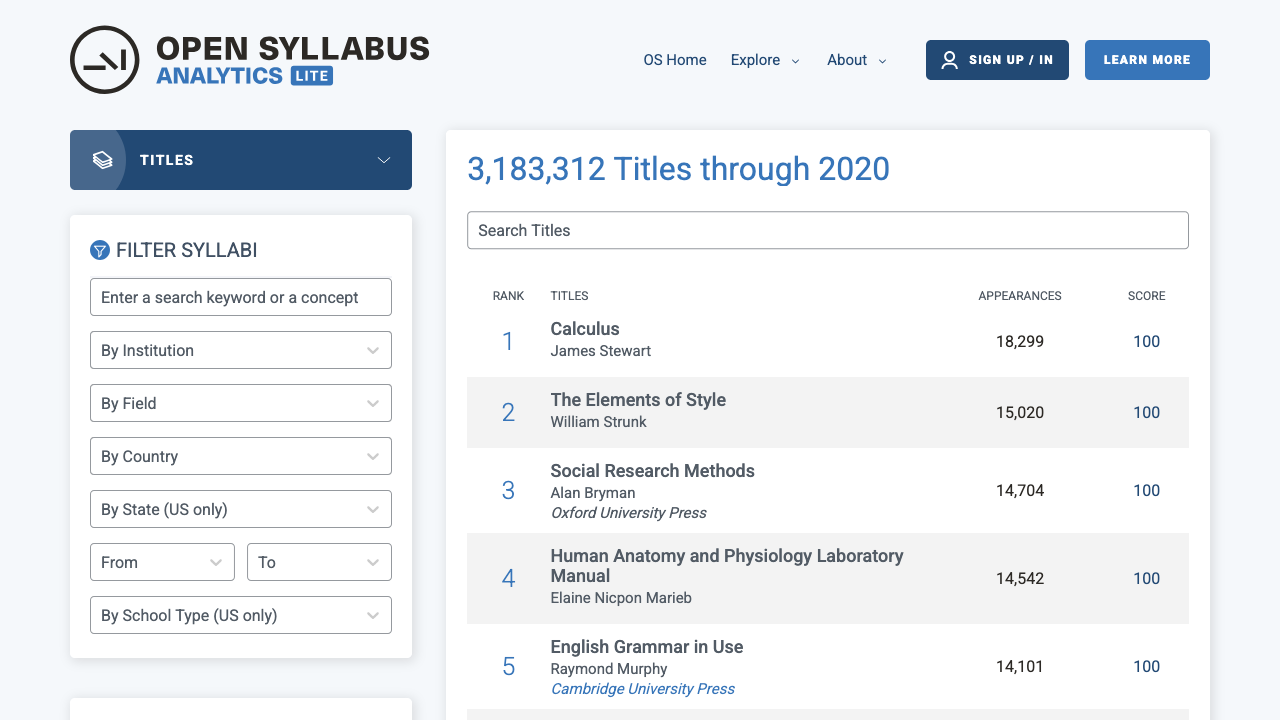

Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
Clicked SHOW MORE, waiting...
All results loaded!


,Rank,Title,Author,Score,Usage Count
0,1,Calculus,James Stewart,100,"18,299"
1,2,The Elements of Style,William Strunk,100,"15,020"
2,3,Social Research Methods,Alan Bryman,100,"14,704"
3,4,Human Anatomy and Physiology Laboratory Manual,Elaine Nicpon Marieb,100,"14,542"
4,5,English Grammar in Use,Raymond Murphy,100,"14,101"


In [20]:
import nest_asyncio
nest_asyncio.apply()

from playwright.async_api import async_playwright
from bs4 import BeautifulSoup
import pandas as pd
from IPython.display import display, Image
import asyncio

async def scrape_opensyllabus():
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        context = await browser.new_context()
        page = await context.new_page()
        await page.goto("https://analytics.opensyllabus.org/record/works", wait_until="networkidle")
        
        # Take initial screenshot
        screenshot_bytes = await page.screenshot()
        display(Image(screenshot_bytes))
        
        # Click SHOW MORE until all results are loaded
        while True:
            button = await page.query_selector("button:has-text('SHOW MORE')")
            if not button:
                print("All results loaded!")
                break
            await button.click()
            print("Clicked SHOW MORE, waiting...")
            await page.wait_for_timeout(2000)
        
        # Grab the HTML while the page is still open
        html = await page.content()
        
        # Parse HTML
        soup = BeautifulSoup(html, "html.parser")
        rows = soup.select("tr.sc-9d100f21-6")
        
        data = []
        for row in rows:
            rank = row.select_one("td:nth-of-type(1) p").get_text(strip=True)
            title = row.select_one("td:nth-of-type(2) li.sc-9d100f21-24 a p").get_text(strip=True)
            author_tag = row.select_one("td:nth-of-type(2) li.cjFXUz a p")
            author = author_tag.get_text(strip=True) if author_tag else ""
            score_tag = row.select_one("td:nth-of-type(4) p")
            score = score_tag.get_text(strip=True) if score_tag else ""
            usage_tag = row.select_one("td:nth-of-type(3) div")
            usage_count = usage_tag.get_text(strip=True) if usage_tag else ""
            
            data.append({
                "Rank": rank,
                "Title": title,
                "Author": author,
                "Score": score,
                "Usage Count": usage_count
            })
        
        df = pd.DataFrame(data)
        return df, browser  # return browser so it stays open

# Run the async function
df, browser = asyncio.get_event_loop().run_until_complete(scrape_opensyllabus())
df.head()  # preview first rows


In [34]:
import asyncio
import nest_asyncio
from playwright.async_api import async_playwright
import pandas as pd
from urllib.parse import urljoin
import os

nest_asyncio.apply()

BASE_URL = "https://cels.baltimorehousing.org/Search_On_Map.aspx"
PDF_BASE = "https://cels.baltimorehousing.org/"
PDF_DIR = "pdfs"

os.makedirs(PDF_DIR, exist_ok=True)
all_rows = []

async def download_pdf(page, url, filename):
    try:
        pdf_bytes = await page.request.get(url)
        with open(filename, "wb") as f:
            f.write(await pdf_bytes.body())
    except Exception as e:
        print(f"❌ Failed to download {url}: {e}")

async def scrape_one_neighborhood(neighborhood_value):
    async with async_playwright() as p:
        browser = await p.firefox.launch(headless=False)
        page = await browser.new_page()
        await page.goto(BASE_URL)

        print(f"\n🟢 Starting neighborhood: {neighborhood_value} {'='*30}")
        await page.select_option("#ctl00_ContentPlaceHolder1_lstLoc", neighborhood_value)
        await page.check("#ctl00_ContentPlaceHolder1_ck2")
        await page.click("#ctl00_ContentPlaceHolder1_btSearch")
        await page.wait_for_selector("tr")

        before_count = len(all_rows)
        page_num = 1

        while True:
            print(f"📄 Scraping page {page_num} …")
            rows = await page.query_selector_all("tr")
            new_rows = 0
            for tr in rows:
                tds = await tr.query_selector_all("td")
                if len(tds) != 7:
                    # skip non-data rows
                    continue

                pdf_el = await tds[6].query_selector("a")
                pdf_url = ""
                pdf_file = ""
                if pdf_el:
                    href = await pdf_el.get_attribute("href")
                    if href and href.lower().endswith(".pdf"):
                        pdf_url = urljoin(PDF_BASE, href)
                        pdf_file = os.path.join(PDF_DIR, os.path.basename(href))
                        await download_pdf(page, pdf_url, pdf_file)

                row = {
                    "Address": (await tds[0].inner_text()).strip(),
                    "Category": (await tds[1].inner_text()).strip(),
                    "Date": (await tds[2].inner_text()).strip(),
                    "ViolationID": (await tds[3].inner_text()).strip(),
                    "Inspector": (await tds[4].inner_text()).strip(),
                    "Neighborhood": (await tds[5].inner_text()).strip(),
                    "PDF": pdf_file
                }
                all_rows.append(row)
                new_rows += 1

            print(f"Added {new_rows} rows from page {page_num} | Total rows now: {len(all_rows)}")

            # check for next page
            next_buttons = await page.query_selector_all("a")
            found_next = False
            for a in next_buttons:
                txt = (await a.inner_text()).strip()
                if txt.lower() == "next":
                    await a.click()
                    await page.wait_for_selector("tr")
                    page_num += 1
                    found_next = True
                    break
            if not found_next:
                break

        after_count = len(all_rows)
        print(f"✅ Finished neighborhood: {neighborhood_value} | Added {after_count - before_count} rows | Total rows: {after_count}")

        await browser.close()

# --- TESTING WITH ONE NEIGHBORHOOD ---
await scrape_one_neighborhood("ABELL")

# Save DataFrame
df = pd.DataFrame(all_rows)
csv_file = "baltimore_scrape_one_neighborhood_clean.csv"
df.to_csv(csv_file, index=False)
print(f"\n🎉 Scraping complete! {len(df)} rows saved to {csv_file}")
print(f"PDFs saved in folder: {PDF_DIR}")



🟢 Starting neighborhood: ABELL ==============================
📄 Scraping page 1 …
Added 54 rows from page 1 | Total rows now: 54
✅ Finished neighborhood: ABELL | Added 54 rows | Total rows: 54

🎉 Scraping complete! 54 rows saved to baltimore_scrape_one_neighborhood_clean.csv
PDFs saved in folder: pdfs
